# EDA Omar

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#Import dataset
df=pd.read_csv(r'C:\Users\omarl\Downloads\VELSIPITY_AFF_MULTIPLI_prepared_prepared_prepared.csv')

## Data general structure understanding

In [ ]:
#Show the data
df.head()

,NUEVO_ID,WEEK_ID,UC_TRX,ORAL_TRX,IL23_TRX,BRAND1_TRX,BRAND2_TRX,UC_NRX,ORAL_NRX,IL23_NRX,...,STATE_6,STS_OTHER_STS,STATE_7,STATE_8,"(1940, 1960]","(1960, 1980]","(1980, 2000]","(2000, 2020]","(2020, 2030]",ATSEG
0,17962,2024-08-02,0.1652,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0,...,0,0,0,0,0,0,0,0,0,NaN
1,3802,2024-11-08,1.5024,0.3780,0.0,0.0,0.0,0.0000,0.0000,0.0,...,0,1,0,0,0,1,0,0,0,SEG_C
2,422,2025-04-25,0.3558,0.1906,0.0,0.0,0.0,0.5337,0.2859,0.0,...,0,0,0,0,1,0,0,0,0,SEG_C
3,19765,2024-02-16,0.0000,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0,...,0,0,0,0,0,0,1,0,0,NaN
4,9647,2024-01-12,0.1652,0.0000,0.0,0.0,0.0,0.2478,0.0000,0.0,...,0,0,0,1,0,1,0,0,0,SEG_A


In [ ]:
#Check its dimensions and data types
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800066 entries, 0 to 1800065
Data columns (total 68 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   NUEVO_ID                  int64  
 1   WEEK_ID                   object 
 2   UC_TRX                    float64
 3   ORAL_TRX                  float64
 4   IL23_TRX                  float64
 5   BRAND1_TRX                float64
 6   BRAND2_TRX                float64
 7   UC_NRX                    float64
 8   ORAL_NRX                  float64
 9   IL23_NRX                  float64
 10  BRAND1_NRX                float64
 11  BRAND2_NRX                float64
 12  N_CLMBRAND3               float64
 13  N_CLMBRAND1               float64
 14  N_CLMBRAND4               float64
 15  N_CLMBRAND2               float64
 16  N_CLMOTHERS               float64
 17  BRAND1_NBRX               float64
 18  BRAND2_NBRX               float64
 19  ORAL_NBRX                 float64
 20  IL23_NBRX               

A total of 1800066 rows and 68 columns.

In [ ]:
#Show the number of unique values per column
print(df.nunique().sort_values(ascending=False).head(20))
print("Doctors:", df["NUEVO_ID"].nunique())
print("Weeks:", df["WEEK_ID"].nunique())
print("Years:", df["YEAR"].nunique())
print("Quarters:", df["QTR"].nunique())
print("Year-Quarter:", df["YEAR_QTR"].nunique())

UC_TRX_R4_16SUM       115800
UC_TRX                 24137
BRAND2_T_GIDX          21900
NUEVO_ID               20931
UC_NRX                 11757
ORAL_TRX                6991
BRAND1_T_GIDX           4606
ORAL_NRX                3308
IL23_TRX                2958
IL23_NRX                1338
BRAND2_TRX               825
BRAND2_NRX               428
BRAND1_TRX               360
BRAND1_NRX               185
BRAND1_NTB_GIDX          145
BRAND2_NTB_GIDX          130
IL23_NBRX_R4_29SUM       130
N_CLMOTHERS               86
WEEK_ID                   86
ORAL_NBRX_R4_29SUM        55
dtype: int64
Doctors: 20931
Weeks: 86
Years: 2
Quarters: 4
Year-Quarter: 7


A total of 20931 unique doctors and 86 weeks.

In [ ]:
#Check the relationship between doctors and weeks
df[["NUEVO_ID", "WEEK_ID"]].duplicated().sum()

0

Each row in the dataset represents a patient-week, meaning that if a patient has been observed for 10 weeks, there will be 10 rows corresponding to that patient, each with a different WEEK_ID. The combination of NUEVO_ID and WEEK_ID should be unique for each row, as it identifies a specific patient at a specific time point. This supports the interpretation that the dataset is recorded at the doctor-week level.

In [ ]:
#Check the consistency of the number of weeks per doctor
weeks_per_doctor = df.groupby("NUEVO_ID")["WEEK_ID"].nunique()
weeks_per_doctor.describe()

count    20931.0
mean        86.0
std          0.0
min         86.0
25%         86.0
50%         86.0
75%         86.0
max         86.0
Name: WEEK_ID, dtype: float64

We can confirm that each doctor has a similar history of weeks by checking the number of unique weeks per doctor. 

I create groups of related columns to facilitate the analysis and understanding of the dataset. 

In [ ]:
#Create groups of related columns
column_groups = {
    "Identifiers": ["NUEVO_ID", "WEEK_ID"],
    "Time": ["YEAR", "QTR", "YEAR_QTR"],
    "Prescription_Total_Class": ["UC_TRX", "ORAL_TRX", "IL23_TRX", "UC_NRX", "ORAL_NRX", "IL23_NRX", "ORAL_NBRX", "IL23_NBRX"],
    "Prescription_Brand": ["BRAND1_TRX", "BRAND2_TRX", "BRAND1_NRX", "BRAND2_NRX", "BRAND1_NBRX", "BRAND2_NBRX"],
    "Claims": ["N_CLMBRAND1", "N_CLMBRAND2", "N_CLMBRAND3", "N_CLMBRAND4", "N_CLMOTHERS",
               "N_CLMBRAND1_NEW", "N_CLMBRAND2_NEW", "N_CLMBRAND3_NEW", "N_CLMBRAND4_NEW", "N_CLMOTHERS_NEW",
               "N_CLMBRAND1_NEW_TO_BRAND", "N_CLMBRAND2_NEW_TO_BRAND", "N_CLMBRAND3NEW_TO_BRAND", "N_CLMBRAND4_NEW_TO_BRAND", "N_CLMOTHERS_NEW_TO_BRAND"],
    "Engagement": ["RTE", "SAMPLES", "COPAY", "DIRECTMAIL", "SPK", "DETAILS"],
    "Rolling_Growth": ["UC_TRX_R4_16SUM", "ORAL_NBRX_R4_29SUM", "IL23_NBRX_R4_29SUM",
                       "BRAND1_NTB_GIDX", "BRAND2_NTB_GIDX", "BRAND1_T_GIDX", "BRAND2_T_GIDX"],
    "Specialty": ["SPEC_GE", "SPEC_GPFM", "SPEC_IM", "SPEC_NRP", "SPEC_OTHER_SPEC", "SPEC_PHA"],
    "State": ["STATE_1", "STATE_2", "STATE_3", "STATE_4", "STATE_5", "STATE_6", "STS_OTHER_STS", "STATE_7", "STATE_8"],
    "Age": ["(1940, 1960]", "(1960, 1980]", "(1980, 2000]", "(2000, 2020]", "(2020, 2030]"],
    "Other": ["ATSEG"]
}

#Create a summary table of the number of variables in each group
summary = pd.DataFrame({
    "group": column_groups.keys(),
    "n_variables": [len(v) for v in column_groups.values()]
})

summary

,group,n_variables
0,Identifiers,2
1,Time,3
2,Prescription_Total_Class,8
3,Prescription_Brand,6
4,Claims,15
5,Engagement,6
6,Rolling_Growth,7
7,Specialty,6
8,State,9
9,Age,5


## Data quality, missing values and basic consistency checks

In [ ]:
#Check the number of missing values per column and the percentage of missing values
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

missing.head(20)

,missing_count,missing_pct
ATSEG,776752,43.151307
BRAND2_T_GIDX,0,0.000000
SPEC_IM,0,0.000000
SPEC_GPFM,0,0.000000
SPEC_GE,0,0.000000
YEAR_QTR,0,0.000000
QTR,0,0.000000
YEAR,0,0.000000
BRAND1_T_GIDX,0,0.000000
WEEK_ID,0,0.000000


There are no missing values except for the ATSEG column, which 43.15% of the values are missing. But this is expected since its the classification column.

In [ ]:
#Check the number of exact duplicates in the dataset
df.duplicated().sum()

0

There are no exact duplicates in the dataset.

In [17]:
dup_doctor_week = df.duplicated(subset=["NUEVO_ID", "WEEK_ID"]).sum()
print("Duplicated doctor-week rows:", dup_doctor_week)

Duplicated doctor-week rows: 0


No duplicates in the combination of NUEVO_ID and WEEK_ID, which confirms that each row represents a unique doctor-week.

In [ ]:
#Dataset consistency checks
checks = {
    "BRAND1_NBRX_leq_NRX": (df["BRAND1_NBRX"] <= df["BRAND1_NRX"]).mean(),
    "BRAND1_NRX_leq_TRX": (df["BRAND1_NRX"] <= df["BRAND1_TRX"]).mean(),
    "BRAND2_NBRX_leq_NRX": (df["BRAND2_NBRX"] <= df["BRAND2_NRX"]).mean(),
    "BRAND2_NRX_leq_TRX": (df["BRAND2_NRX"] <= df["BRAND2_TRX"]).mean(),
}

pd.Series(checks)

BRAND1_NBRX_leq_NRX    0.999187
BRAND1_NRX_leq_TRX     0.998960
BRAND2_NBRX_leq_NRX    0.998991
BRAND2_NRX_leq_TRX     0.996761
dtype: float64

We can see that the dataset is almost a 100% consistent in logical amount relationships.

In [33]:
df[df["BRAND1_NBRX"] > df["BRAND1_NRX"]][["BRAND1_NBRX", "BRAND1_NRX"]].count()

BRAND1_NBRX    1463
BRAND1_NRX     1463
dtype: int64

In [32]:
df[df["BRAND1_NRX"] > df["BRAND1_TRX"]][["BRAND1_NRX", "BRAND1_TRX"]].count()

BRAND1_NRX    1872
BRAND1_TRX    1872
dtype: int64

In [31]:
df[df["BRAND2_NBRX"] > df["BRAND2_NRX"]][["BRAND2_NBRX", "BRAND2_NRX"]].count()

BRAND2_NBRX    1817
BRAND2_NRX     1817
dtype: int64

In [30]:
df[df["BRAND2_NRX"] > df["BRAND2_TRX"]][["BRAND2_NRX", "BRAND2_TRX"]].count()

BRAND2_NRX    5830
BRAND2_TRX    5830
dtype: int64

We show the amount of inconsistencies in the dataset.

In [ ]:
#Look for negative values in count columns
count_cols = [
    "UC_TRX", "ORAL_TRX", "IL23_TRX",
    "UC_NRX", "ORAL_NRX", "IL23_NRX",
    "BRAND1_TRX", "BRAND2_TRX",
    "BRAND1_NRX", "BRAND2_NRX",
    "BRAND1_NBRX", "BRAND2_NBRX",
    "RTE", "SAMPLES", "COPAY", "DIRECTMAIL", "SPK", "DETAILS"
]

negatives = {col: (df[col] < 0).sum() for col in count_cols if col in df.columns}
pd.Series(negatives).sort_values(ascending=False)

ORAL_NRX       1
UC_TRX         0
BRAND1_NBRX    0
SPK            0
DIRECTMAIL     0
COPAY          0
SAMPLES        0
RTE            0
BRAND2_NBRX    0
BRAND2_NRX     0
ORAL_TRX       0
BRAND1_NRX     0
BRAND2_TRX     0
BRAND1_TRX     0
IL23_NRX       0
UC_NRX         0
IL23_TRX       0
DETAILS        0
dtype: int64

We can see that only ORAL_NRX has a negative value out of all these columns which should always be positive. 

In [41]:
df.describe().T[["min", "max", "mean", "std"]].sort_values("min", ascending=True).head(20)

,min,max,mean,std
BRAND2_T_GIDX,-13.784647,20.307795,0.057552,0.649436
BRAND1_T_GIDX,-9.017364,20.159676,0.022930,0.343933
BRAND1_NTB_GIDX,-7.481565,7.482217,0.005399,0.126942
BRAND2_NTB_GIDX,-5.419216,5.166614,0.005160,0.148762
ORAL_NRX,-0.000300,9.696000,0.024264,0.122780
COPAY,0.000000,5.000000,0.003176,0.062834
SPK,0.000000,2.000000,0.001266,0.035692
DETAILS,0.000000,3.000000,0.056332,0.189447
UC_TRX_R4_16SUM,0.000000,203.151400,3.008686,6.632048
ORAL_NBRX_R4_29SUM,0.000000,46.900000,0.348194,0.910593


Out of all the columns, we can see that also the growth indexes columns have negative values.

In [ ]:
#Look for low variance columns
low_variance = df.nunique().sort_values()
low_variance.head(20)

(2000, 2020]       1
(2020, 2030]       1
STATE_2            2
SPEC_GPFM          2
SPEC_IM            2
SPEC_NRP           2
SPEC_OTHER_SPEC    2
SPEC_PHA           2
STATE_1            2
SPEC_GE            2
STATE_3            2
YEAR               2
STATE_5            2
STATE_6            2
STS_OTHER_STS      2
STATE_7            2
STATE_8            2
(1940, 1960]       2
(1960, 1980]       2
(1980, 2000]       2
dtype: int64

## Numeric variables distribution and sparsity

In [ ]:
#Generate a summary table of statistics for the main numeric columns
num_cols_main = [
    "UC_TRX", "ORAL_TRX", "IL23_TRX",
    "BRAND1_TRX", "BRAND2_TRX",
    "UC_NRX", "ORAL_NRX", "IL23_NRX",
    "BRAND1_NRX", "BRAND2_NRX",
    "BRAND1_NBRX", "BRAND2_NBRX",
    "RTE", "SAMPLES", "COPAY", "DIRECTMAIL", "SPK", "DETAILS"
]

summary_stats = df[num_cols_main].describe().T
summary_stats["median"] = df[num_cols_main].median()
summary_stats["skew"] = df[num_cols_main].skew()
summary_stats["zeros_pct"] = (df[num_cols_main] == 0).mean() * 100

summary_stats[["mean", "median", "std", "min", "max", "skew", "zeros_pct"]].sort_values("skew", ascending=False)

,mean,median,std,min,max,skew,zeros_pct
BRAND1_NRX,0.000382,0.0,0.013124,0.0000,1.9950,48.056572,99.891171
RTE,0.032131,0.0,0.364557,0.0000,107.0000,36.743892,98.819210
BRAND1_NBRX,0.000580,0.0,0.020446,0.0000,1.4000,36.229274,99.918447
BRAND2_NBRX,0.000715,0.0,0.022557,0.0000,1.4000,32.031794,99.898726
IL23_NRX,0.014391,0.0,0.104780,0.0000,15.4536,31.852719,96.456408
SPK,0.001266,0.0,0.035692,0.0000,2.0000,28.386295,99.873949
BRAND1_TRX,0.000710,0.0,0.013994,0.0000,1.4534,27.592681,99.682401
IL23_TRX,0.026980,0.0,0.141944,0.0000,17.8268,26.262868,91.826744
BRAND2_NRX,0.001238,0.0,0.023718,0.0000,1.3125,25.318574,99.646902
COPAY,0.003176,0.0,0.062834,0.0000,5.0000,23.252086,99.717344


In [ ]:
#Plot boxplots for the main numeric columns
def plot_boxplots(df, cols, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    df[cols].boxplot(rot=45)
    plt.title("Boxplots of selected variables")
    plt.show()

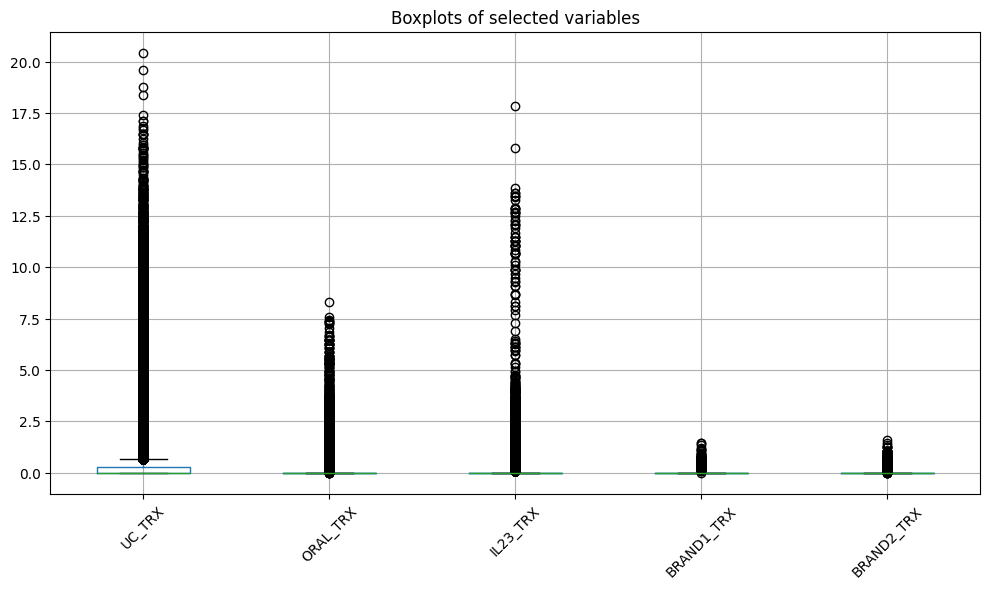

In [54]:
plot_boxplots(df, ["UC_TRX", "ORAL_TRX", "IL23_TRX", "BRAND1_TRX", "BRAND2_TRX"])

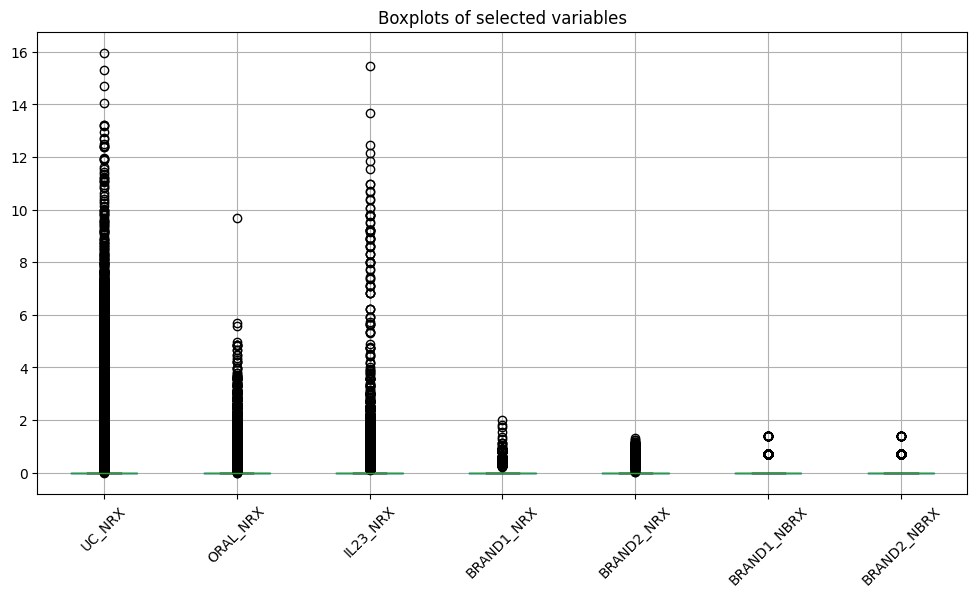

In [56]:
plot_boxplots(df, ["UC_NRX", "ORAL_NRX", "IL23_NRX",
    "BRAND1_NRX", "BRAND2_NRX",
    "BRAND1_NBRX", "BRAND2_NBRX"    ])

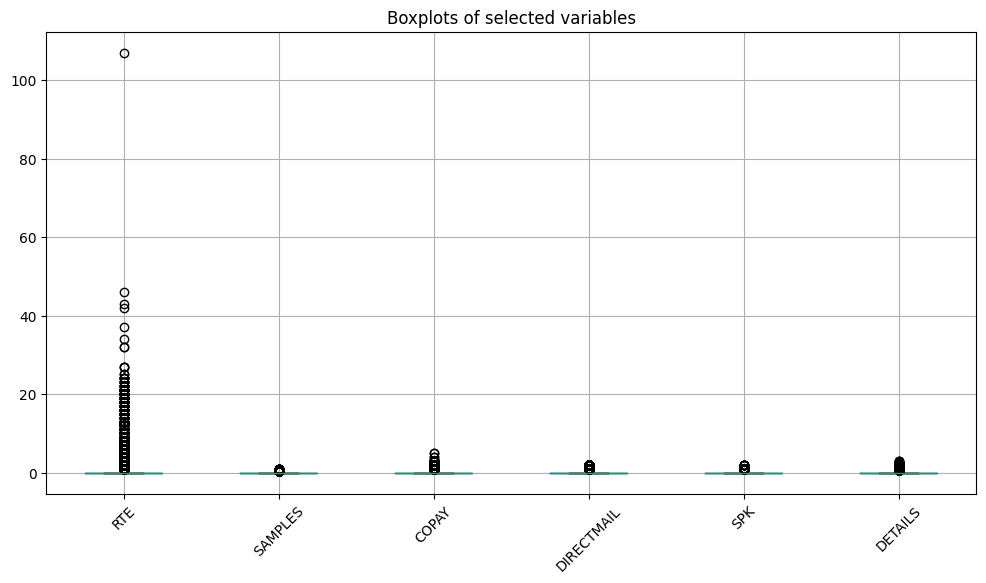

In [55]:
plot_boxplots(df, ["RTE", "SAMPLES", "COPAY", "DIRECTMAIL", "SPK", "DETAILS"])

We can see in all the boxplots that most of the numeric variables are located in the lower part of the graph with lots of outliers in the upper part. 

In [ ]:
#Show the percentage of zero values in each numeric column
zero_pct = (df[num_cols_main] == 0).mean().sort_values(ascending=False) * 100
zero_pct

BRAND1_NBRX    99.918447
BRAND2_NBRX    99.898726
BRAND1_NRX     99.891171
SPK            99.873949
COPAY          99.717344
BRAND1_TRX     99.682401
BRAND2_NRX     99.646902
SAMPLES        99.615236
RTE            98.819210
BRAND2_TRX     98.640883
IL23_NRX       96.456408
DIRECTMAIL     94.824968
ORAL_NRX       94.323375
IL23_TRX       91.826744
DETAILS        91.297930
ORAL_TRX       85.471533
UC_NRX         80.000067
UC_TRX         58.179756
dtype: float64

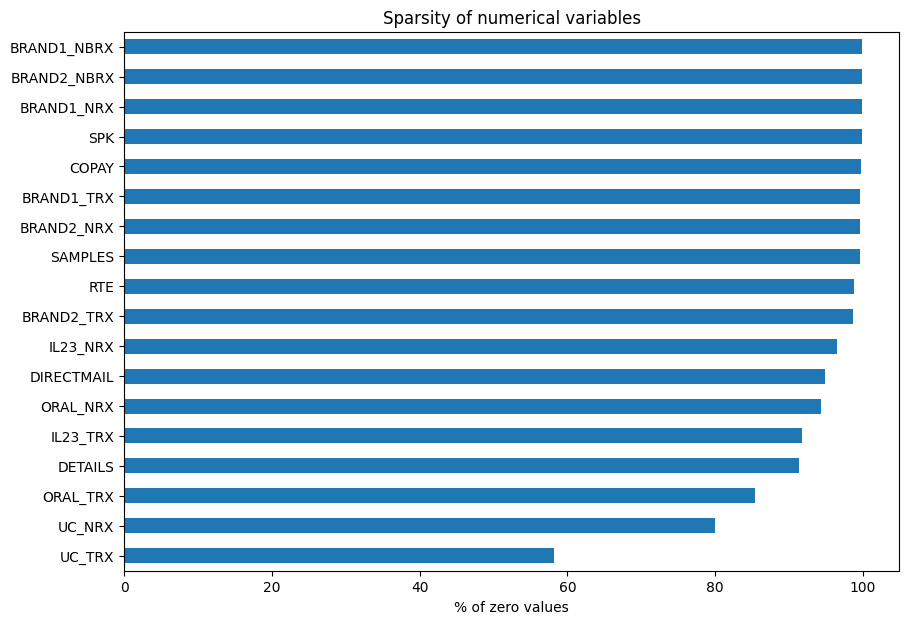

In [58]:
plt.figure(figsize=(10, 7))
zero_pct.sort_values().plot(kind="barh")
plt.xlabel("% of zero values")
plt.title("Sparsity of numerical variables")
plt.show()

We can see that the numerical variables show a very high sparsity, with a large number of zero values. 

In [ ]:
#Show the percentage of outliers in each numeric column using the IQR method
def outlier_pct_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).mean() * 100

outlier_summary = pd.DataFrame({
    "outlier_pct": [outlier_pct_iqr(df[col].dropna()) for col in num_cols_main]
}, index=num_cols_main).sort_values("outlier_pct", ascending=False)

outlier_summary

,outlier_pct
UC_NRX,19.999933
ORAL_TRX,14.528467
UC_TRX,10.753495
DETAILS,8.702070
IL23_TRX,8.173256
ORAL_NRX,5.676625
DIRECTMAIL,5.175032
IL23_NRX,3.543592
BRAND2_TRX,1.359117
RTE,1.180790


## Categorical variables and doctor profile

In [ ]:
#Show the frequency of each specialty in the dataset
spec_cols = ["SPEC_GE", "SPEC_GPFM", "SPEC_IM", "SPEC_NRP", "SPEC_OTHER_SPEC", "SPEC_PHA"]
spec_counts = df[spec_cols].sum().sort_values(ascending=False)
spec_counts

SPEC_GE            1422526
SPEC_IM             216376
SPEC_PHA             60974
SPEC_NRP             60888
SPEC_GPFM            20640
SPEC_OTHER_SPEC      18662
dtype: int64

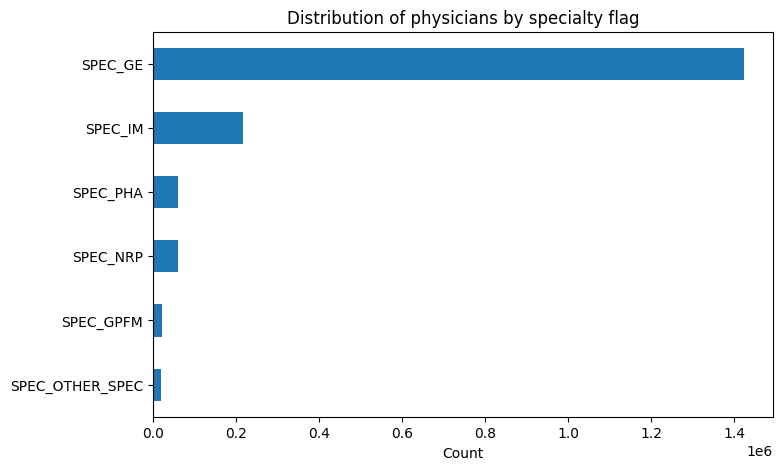

In [62]:
plt.figure(figsize=(8,5))
spec_counts.sort_values().plot(kind="barh")
plt.title("Distribution of physicians by specialty flag")
plt.xlabel("Count")
plt.show()

In [67]:
df["specialty_label"] = df[spec_cols].idxmax(axis=1)
df["specialty_label"].value_counts()

specialty_label
SPEC_GE            1422526
SPEC_IM             216376
SPEC_PHA             60974
SPEC_NRP             60888
SPEC_GPFM            20640
SPEC_OTHER_SPEC      18662
Name: count, dtype: int64

In [ ]:
#Frequency of each state in the dataset
state_cols = ["STATE_1", "STATE_2", "STATE_3", "STATE_4", "STATE_5", "STATE_6", "STATE_7", "STATE_8", "STS_OTHER_STS"]
state_counts = df[state_cols].sum().sort_values(ascending=False)
state_counts

STS_OTHER_STS    964060
STATE_1          151532
STATE_5          143534
STATE_2          137170
STATE_8          125044
STATE_7           81614
STATE_6           68800
STATE_3           67166
STATE_4           61146
dtype: int64

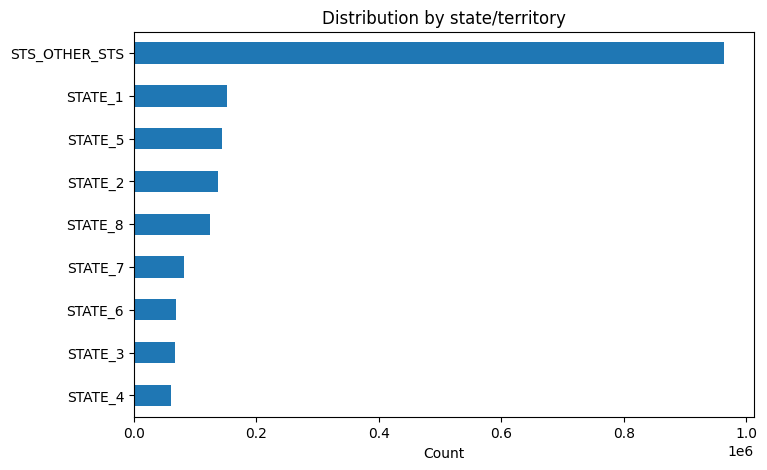

In [65]:
plt.figure(figsize=(8,5))
state_counts.sort_values().plot(kind="barh")
plt.title("Distribution by state/territory")
plt.xlabel("Count")
plt.show()

In [66]:
df["state_label"] = df[state_cols].idxmax(axis=1)
df["state_label"].value_counts()

state_label
STS_OTHER_STS    964060
STATE_1          151532
STATE_5          143534
STATE_2          137170
STATE_8          125044
STATE_7           81614
STATE_6           68800
STATE_3           67166
STATE_4           61146
Name: count, dtype: int64

In [ ]:
#Frequency of each age group in the dataset
age_cols = ["(1940, 1960]", "(1960, 1980]", "(1980, 2000]", "(2000, 2020]", "(2020, 2030]"]
age_counts = df[age_cols].sum().sort_values(ascending=False)
age_counts

(1960, 1980]    659190
(1980, 2000]    600796
(1940, 1960]    219644
(2000, 2020]         0
(2020, 2030]         0
dtype: int64

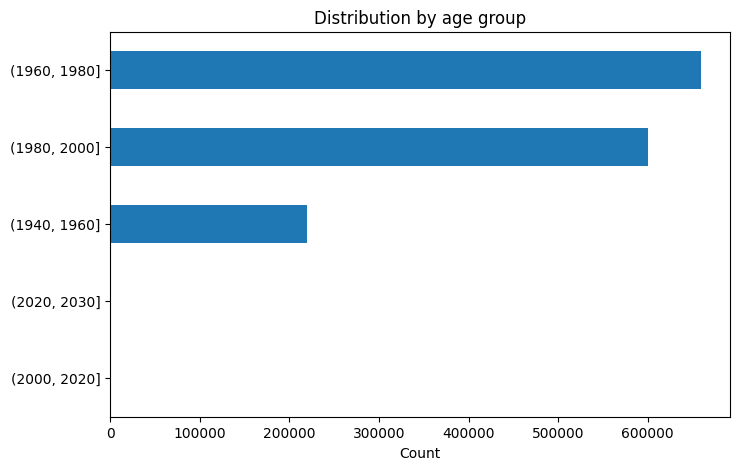

In [69]:
plt.figure(figsize=(8,5))
age_counts.sort_values().plot(kind="barh")
plt.title("Distribution by age group")
plt.xlabel("Count")
plt.show()

In [70]:
df["age_group"] = df[age_cols].idxmax(axis=1)
df["age_group"].value_counts()

age_group
(1960, 1980]    659190
(1980, 2000]    600796
(1940, 1960]    540080
Name: count, dtype: int64

In [ ]:
#Frequency of each ATSEG segment in the dataset
df["ATSEG"].value_counts(dropna=False)

ATSEG
NaN      776752
SEG_A    550916
SEG_B    288014
SEG_C    184384
Name: count, dtype: int64

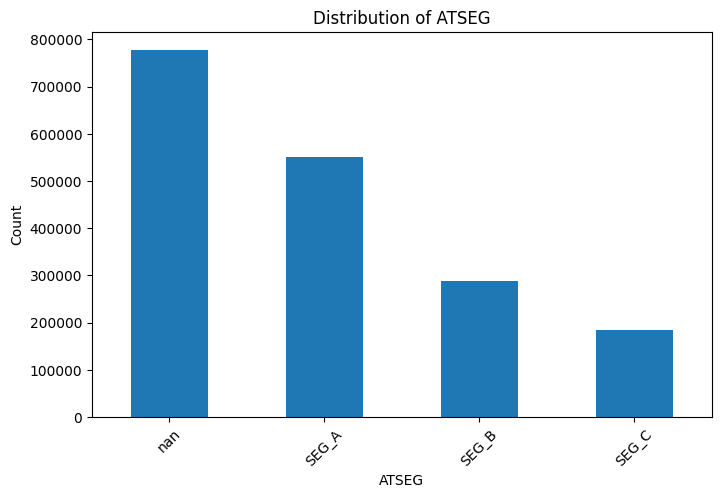

In [72]:
plt.figure(figsize=(8,5))
df["ATSEG"].value_counts(dropna=False).plot(kind="bar")
plt.title("Distribution of ATSEG")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Create a doctor-level profile dataset by dropping duplicate doctor IDs
doctor_profile = df.drop_duplicates(subset=["NUEVO_ID"]).copy()

In [74]:
doctor_profile[spec_cols].sum().sort_values(ascending=False)
doctor_profile[state_cols].sum().sort_values(ascending=False)
doctor_profile[age_cols].sum().sort_values(ascending=False)
doctor_profile["ATSEG"].value_counts(dropna=False)

ATSEG
NaN      9032
SEG_A    6406
SEG_B    3349
SEG_C    2144
Name: count, dtype: int64

Since specialty, territory, and age group are doctor-level attributes, their distribution is more meaningfully assessed at the unique-doctor level rather than across all physician-week observations.

In [ ]:
#Show the percentage of doctors in each ATSEG segment
doctor_profile["ATSEG"].value_counts(normalize=True, dropna=False) * 100

ATSEG
NaN      43.151307
SEG_A    30.605322
SEG_B    16.000191
SEG_C    10.243180
Name: proportion, dtype: float64

In [ ]:
#Show the average prescriptions by specialty
df.groupby("specialty_label")[["UC_TRX", "BRAND1_TRX", "BRAND1_NRX"]].mean().sort_values("BRAND1_TRX", ascending=False)

,UC_TRX,BRAND1_TRX,BRAND1_NRX
specialty_label,,,
SPEC_OTHER_SPEC,0.300003,0.001237,0.000730
SPEC_GE,0.283776,0.000868,0.000463
SPEC_NRP,0.101541,0.000122,0.000052
SPEC_GPFM,0.123405,0.000102,0.000085
SPEC_PHA,0.096034,0.000090,0.000093
SPEC_IM,0.070568,0.000029,0.000024


In [ ]:
#Show the average engagement metrics by specialty
df.groupby("specialty_label")[["RTE", "DETAILS", "SAMPLES", "COPAY"]].mean().sort_values("DETAILS", ascending=False)

,RTE,DETAILS,SAMPLES,COPAY
specialty_label,,,,
SPEC_GE,0.039748,0.069612,0.002383,0.003915
SPEC_GPFM,0.019622,0.042849,0.001260,0.000630
SPEC_OTHER_SPEC,0.024113,0.030865,0.000911,0.005573
SPEC_NRP,0.003416,0.006228,0.000263,0.000115
SPEC_PHA,0.001738,0.005747,0.000238,0.000049
SPEC_IM,0.000582,0.000857,0.000030,0.000097


In [ ]:
#Show the average prescriptions by age group
df.groupby("age_group")[["UC_TRX", "BRAND1_TRX", "BRAND1_NRX"]].mean().sort_values("BRAND1_TRX", ascending=False)

,UC_TRX,BRAND1_TRX,BRAND1_NRX
age_group,,,
"(1960, 1980]",0.320382,0.000855,0.000445
"(1980, 2000]",0.207088,0.000654,0.000348
"(1940, 1960]",0.191680,0.000596,0.000344


In [ ]:
#Show the average prescriptions by state
df.groupby("state_label")[["UC_TRX", "BRAND1_TRX", "DETAILS"]].mean().sort_values("BRAND1_TRX", ascending=False)

,UC_TRX,BRAND1_TRX,DETAILS
state_label,,,
STATE_4,0.235923,0.001205,0.108223
STATE_5,0.281526,0.001151,0.074750
STATE_3,0.253515,0.001098,0.062174
STATE_2,0.187972,0.000766,0.073901
STATE_8,0.208156,0.000730,0.055171
STS_OTHER_STS,0.260507,0.000633,0.050659
STATE_7,0.249875,0.000594,0.046507
STATE_1,0.172835,0.000556,0.039996
STATE_6,0.257709,0.000385,0.060288


## Temporal analysis

In [88]:
weekly_ts = df.groupby("WEEK_ID")[[
    "UC_TRX", "BRAND1_TRX", "BRAND1_NRX", "BRAND1_NBRX", "BRAND2_TRX", "BRAND2_NRX", "BRAND2_NBRX",
    "DETAILS", "RTE", "SAMPLES"
]].sum()

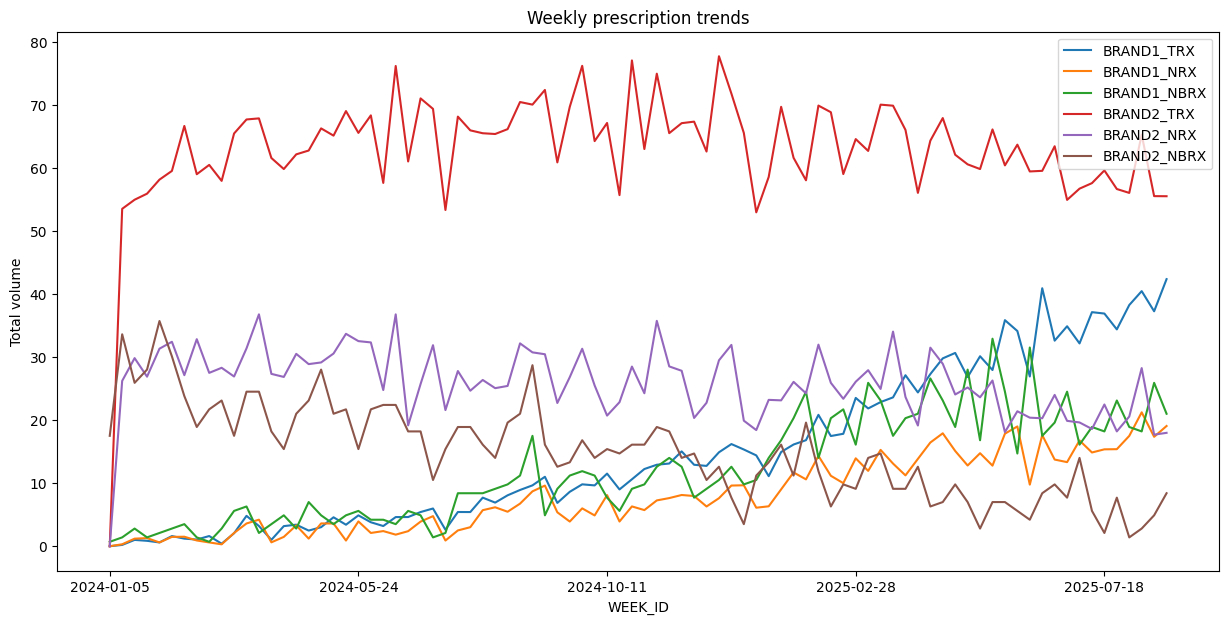

In [91]:
weekly_ts[["BRAND1_TRX", "BRAND1_NRX", "BRAND1_NBRX", "BRAND2_TRX", "BRAND2_NRX", "BRAND2_NBRX"]].plot(figsize=(15,7))
plt.title("Weekly prescription trends")
plt.xlabel("WEEK_ID")
plt.ylabel("Total volume")
plt.show()

Comparison of the time series of both brands prescriptions.

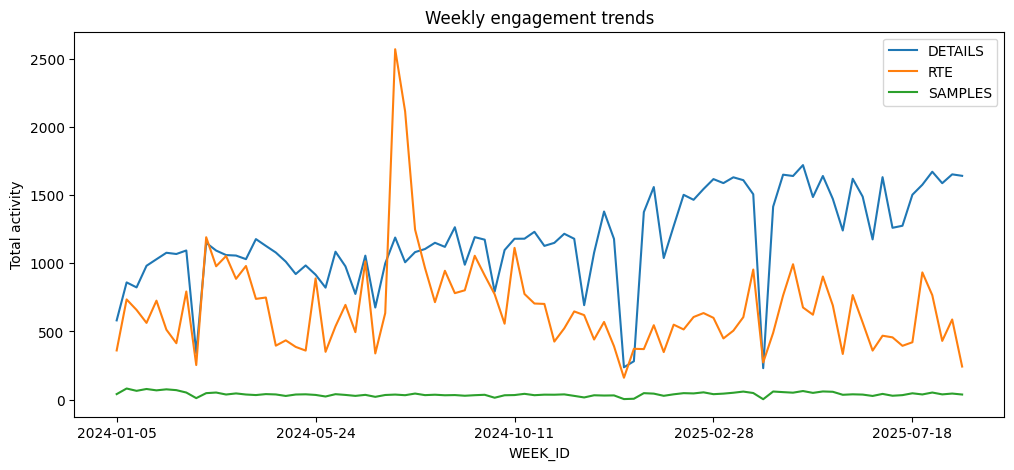

In [87]:
weekly_ts[["DETAILS", "RTE", "SAMPLES"]].plot(figsize=(12,5))
plt.title("Weekly engagement trends")
plt.xlabel("WEEK_ID")
plt.ylabel("Total activity")
plt.show()

Comparison of engagement metrics over time.

In [92]:
quarterly_ts=df.groupby("YEAR_QTR")[["UC_TRX", "BRAND1_TRX", "BRAND1_NRX", "BRAND1_NBRX", "BRAND2_TRX", "BRAND2_NRX", "BRAND2_NBRX",
    "DETAILS", "RTE", "SAMPLES"]].sum()

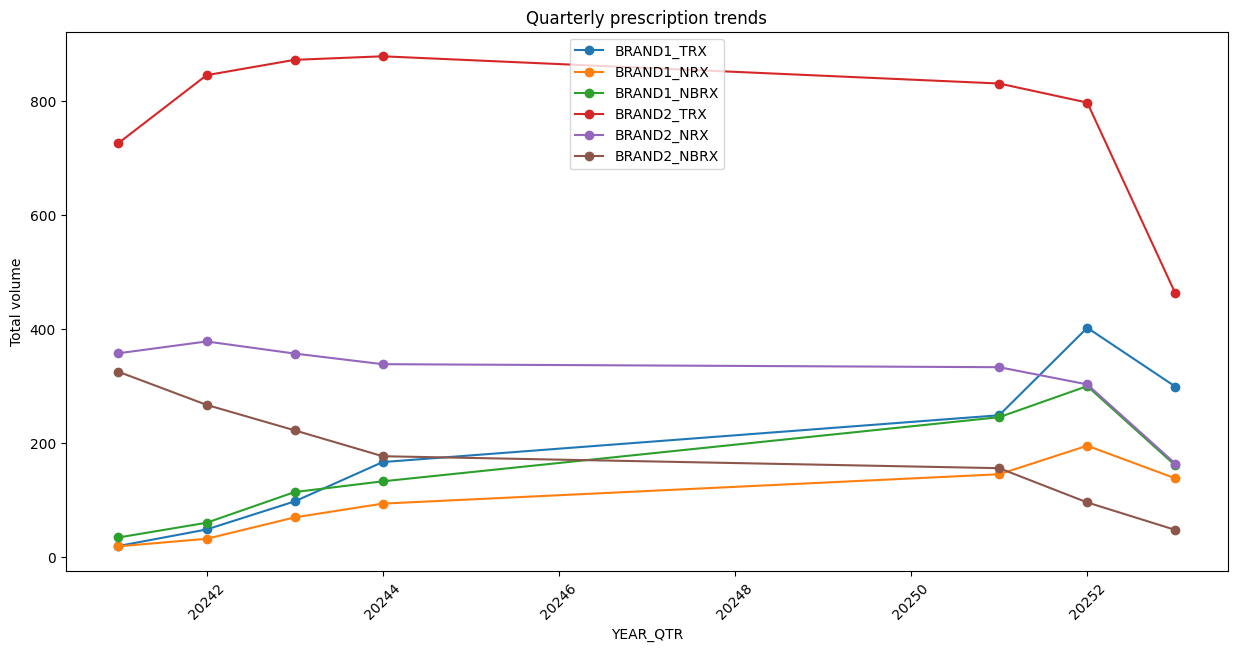

In [97]:
quarterly_ts[["BRAND1_TRX", "BRAND1_NRX", "BRAND1_NBRX", "BRAND2_TRX", "BRAND2_NRX", "BRAND2_NBRX"]].plot(figsize=(15,7), marker="o")
plt.title("Quarterly prescription trends")
plt.xlabel("YEAR_QTR")
plt.ylabel("Total volume")
plt.xticks(rotation=45)
plt.show()

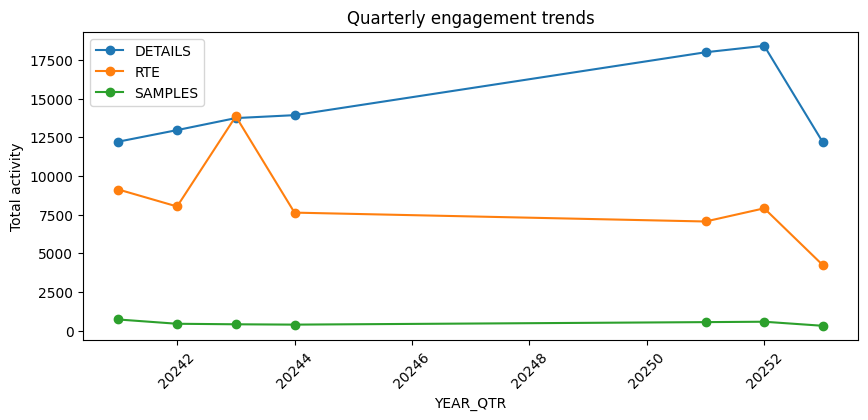

In [95]:
quarterly_ts[["DETAILS", "RTE", "SAMPLES"]].plot(figsize=(10,4), marker="o")
plt.title("Quarterly engagement trends")
plt.xlabel("YEAR_QTR")
plt.ylabel("Total activity")
plt.xticks(rotation=45)
plt.show()

We repeat the same graphs but at a quarterly level to see if it helps to identify trends more clearly.

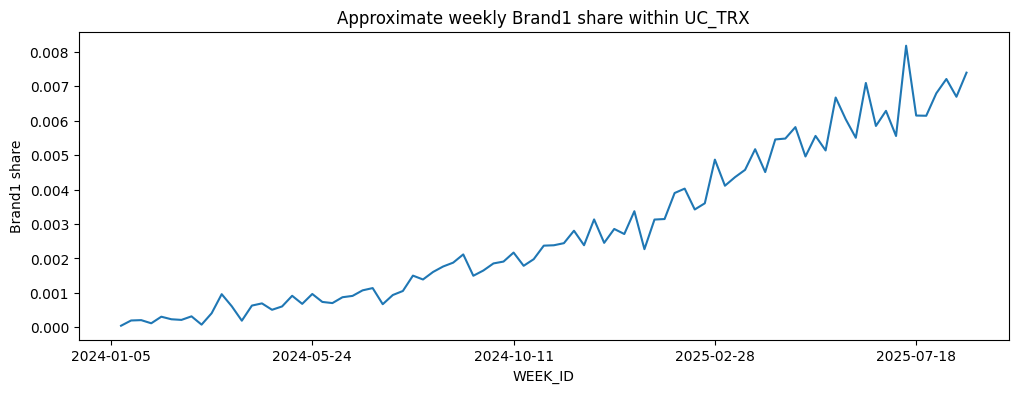

In [99]:
weekly_share = df.groupby("WEEK_ID")[["BRAND1_TRX", "UC_TRX"]].sum()
weekly_share["brand1_share"] = weekly_share["BRAND1_TRX"] / weekly_share["UC_TRX"].replace(0, np.nan)

plt.figure(figsize=(12,4))
weekly_share["brand1_share"].plot()
plt.title("Approximate weekly Brand1 share within UC_TRX")
plt.xlabel("WEEK_ID")
plt.ylabel("Brand1 share")
plt.show()

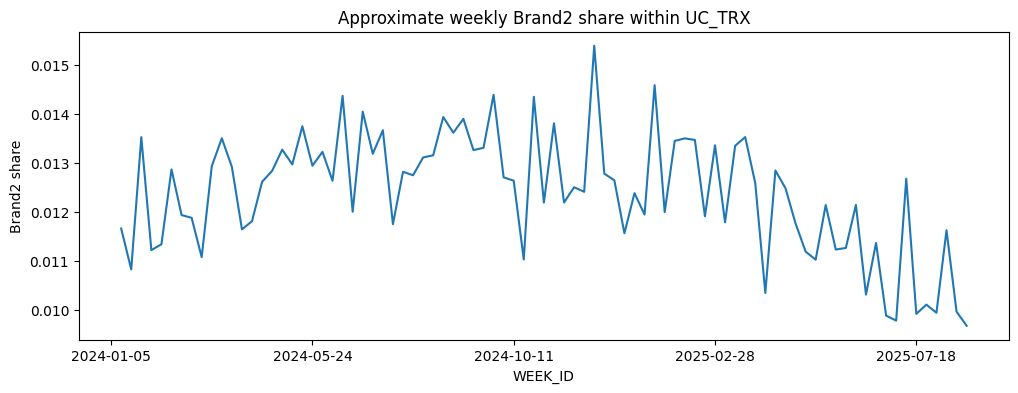

In [100]:
weekly_share = df.groupby("WEEK_ID")[["BRAND2_TRX", "UC_TRX"]].sum()
weekly_share["brand2_share"] = weekly_share["BRAND2_TRX"] / weekly_share["UC_TRX"].replace(0, np.nan)

plt.figure(figsize=(12,4))
weekly_share["brand2_share"].plot()
plt.title("Approximate weekly Brand2 share within UC_TRX")
plt.xlabel("WEEK_ID")
plt.ylabel("Brand2 share")
plt.show()

We show the evolution of both brands weekly share within the total UC_TRX to see if there are any trends in the market share of both brands.

## Relationship between variables and correlation analysis

In [ ]:
#Show correlation matrix for prescription variables
presc_cols = [
    "UC_TRX", "ORAL_TRX", "IL23_TRX",
    "UC_NRX", "ORAL_NRX", "IL23_NRX",
    "BRAND1_TRX", "BRAND2_TRX",
    "BRAND1_NRX", "BRAND2_NRX",
    "BRAND1_NBRX", "BRAND2_NBRX"
]

corr_presc = df[presc_cols].corr()
corr_presc

,UC_TRX,ORAL_TRX,IL23_TRX,UC_NRX,ORAL_NRX,IL23_NRX,BRAND1_TRX,BRAND2_TRX,BRAND1_NRX,BRAND2_NRX,BRAND1_NBRX,BRAND2_NBRX
UC_TRX,1.000000,0.729493,0.630513,0.818861,0.512319,0.479535,0.102168,0.176143,0.056580,0.090683,0.039147,0.033539
ORAL_TRX,0.729493,1.000000,0.410201,0.606402,0.724126,0.297282,0.172246,0.276440,0.099370,0.151919,0.046335,0.031219
IL23_TRX,0.630513,0.410201,1.000000,0.548086,0.273544,0.803113,0.078458,0.083203,0.037147,0.038706,0.033668,0.018257
UC_NRX,0.818861,0.606402,0.548086,1.000000,0.620426,0.548421,0.085310,0.132548,0.072901,0.118581,0.031430,0.024802
ORAL_NRX,0.512319,0.724126,0.273544,0.620426,1.000000,0.214797,0.125610,0.179257,0.138253,0.229012,0.032175,0.019763
IL23_NRX,0.479535,0.297282,0.803113,0.548421,0.214797,1.000000,0.052042,0.055158,0.027039,0.028140,0.020704,0.012360
BRAND1_TRX,0.102168,0.172246,0.078458,0.085310,0.125610,0.052042,1.000000,0.037131,0.647420,0.017262,0.034143,0.004953
BRAND2_TRX,0.176143,0.276440,0.083203,0.132548,0.179257,0.055158,0.037131,1.000000,0.018712,0.583290,0.023537,0.027752
BRAND1_NRX,0.056580,0.099370,0.037147,0.072901,0.138253,0.027039,0.647420,0.018712,1.000000,0.007401,0.026943,0.002897
BRAND2_NRX,0.090683,0.151919,0.038706,0.118581,0.229012,0.028140,0.017262,0.583290,0.007401,1.000000,0.015592,0.016282


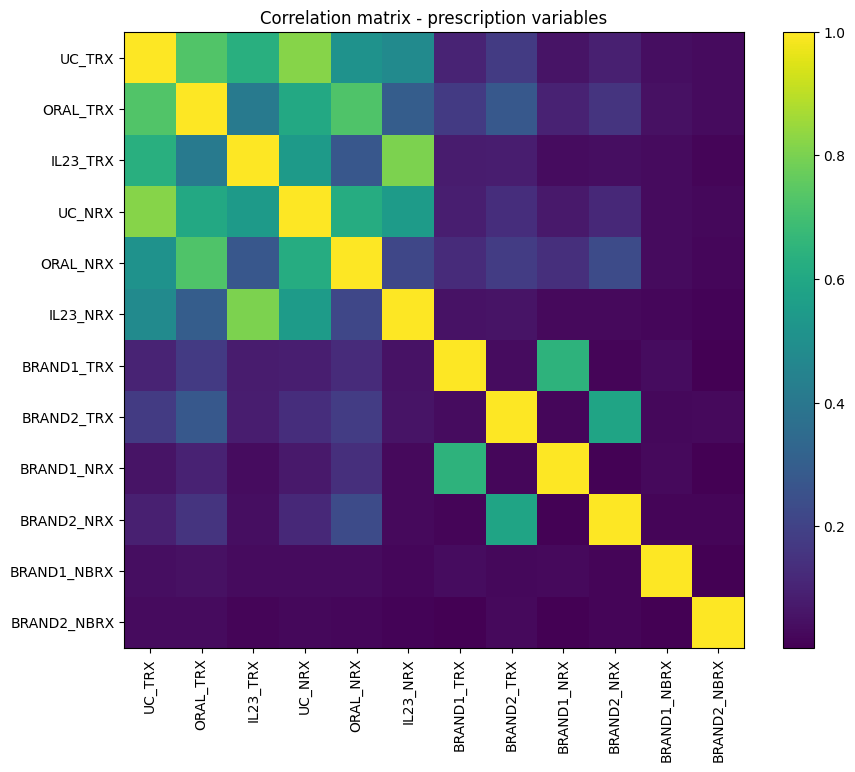

In [104]:
plt.figure(figsize=(10,8))
plt.imshow(corr_presc, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_presc.columns)), corr_presc.columns, rotation=90)
plt.yticks(range(len(corr_presc.index)), corr_presc.index)
plt.title("Correlation matrix - prescription variables")
plt.show()

The main correlations exclude the brand prescriptions variables, which are not really correlated neither with each other or with the rest of the variables.

In [ ]:
#Show correlation matrix for engagement variables
engagement_cols = ["RTE", "SAMPLES", "COPAY", "DIRECTMAIL", "SPK", "DETAILS"]

corr_eng = df[engagement_cols].corr()
corr_eng

,RTE,SAMPLES,COPAY,DIRECTMAIL,SPK,DETAILS
RTE,1.000000,0.018675,0.005707,0.065768,0.004219,0.072089
SAMPLES,0.018675,1.000000,0.018788,0.026872,0.007323,0.200472
COPAY,0.005707,0.018788,1.000000,0.008960,0.009107,0.049402
DIRECTMAIL,0.065768,0.026872,0.008960,1.000000,0.015229,0.110677
SPK,0.004219,0.007323,0.009107,0.015229,1.000000,0.065963
DETAILS,0.072089,0.200472,0.049402,0.110677,0.065963,1.000000


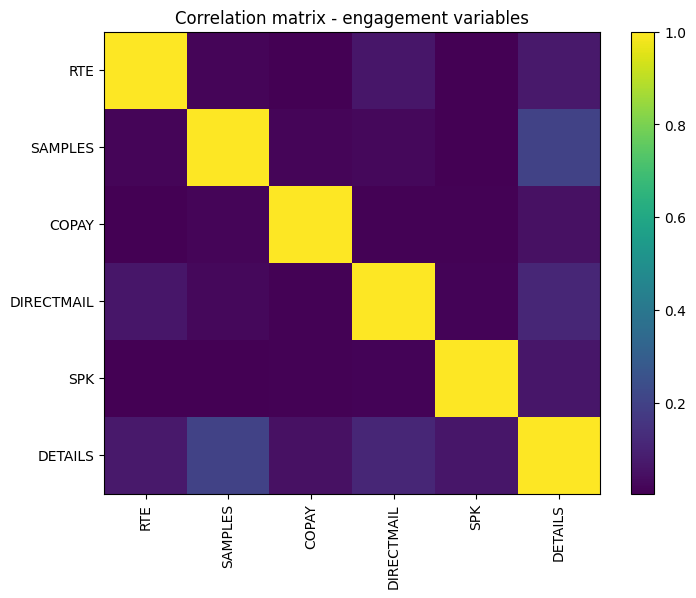

In [106]:
plt.figure(figsize=(8,6))
plt.imshow(corr_eng, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_eng.columns)), corr_eng.columns, rotation=90)
plt.yticks(range(len(corr_eng.index)), corr_eng.index)
plt.title("Correlation matrix - engagement variables")
plt.show()

There is almost no correlation between the engagement metrics.

In [ ]:
#Show correlation matrix for claims variables
claims_cols = [
    "N_CLMBRAND1", "N_CLMBRAND2", "N_CLMOTHERS",
    "N_CLMBRAND1_NEW", "N_CLMBRAND2_NEW", "N_CLMOTHERS_NEW",
    "N_CLMBRAND1_NEW_TO_BRAND", "N_CLMBRAND2_NEW_TO_BRAND", "N_CLMOTHERS_NEW_TO_BRAND"
]

claims_cols = [c for c in claims_cols if c in df.columns]
corr_claims = df[claims_cols].corr()
corr_claims

,N_CLMBRAND1,N_CLMBRAND2,N_CLMOTHERS,N_CLMBRAND1_NEW,N_CLMBRAND2_NEW,N_CLMOTHERS_NEW,N_CLMBRAND1_NEW_TO_BRAND,N_CLMBRAND2_NEW_TO_BRAND,N_CLMOTHERS_NEW_TO_BRAND
N_CLMBRAND1,1.000000,0.044636,0.076605,0.334397,0.023145,0.054520,0.514527,0.006515,0.045564
N_CLMBRAND2,0.044636,1.000000,0.159272,0.013084,0.471392,0.113169,0.023488,0.299157,0.085402
N_CLMOTHERS,0.076605,0.159272,1.000000,0.029900,0.079932,0.774583,0.034965,0.037073,0.539059
N_CLMBRAND1_NEW,0.334397,0.013084,0.029900,1.000000,0.007924,0.026059,0.015526,-0.000607,0.016323
N_CLMBRAND2_NEW,0.023145,0.471392,0.079932,0.007924,1.000000,0.065680,0.014598,0.064110,0.042456
N_CLMOTHERS_NEW,0.054520,0.113169,0.774583,0.026059,0.065680,1.000000,0.026030,0.026718,0.356149
N_CLMBRAND1_NEW_TO_BRAND,0.514527,0.023488,0.034965,0.015526,0.014598,0.026030,1.000000,0.007360,0.022924
N_CLMBRAND2_NEW_TO_BRAND,0.006515,0.299157,0.037073,-0.000607,0.064110,0.026718,0.007360,1.000000,0.024497
N_CLMOTHERS_NEW_TO_BRAND,0.045564,0.085402,0.539059,0.016323,0.042456,0.356149,0.022924,0.024497,1.000000


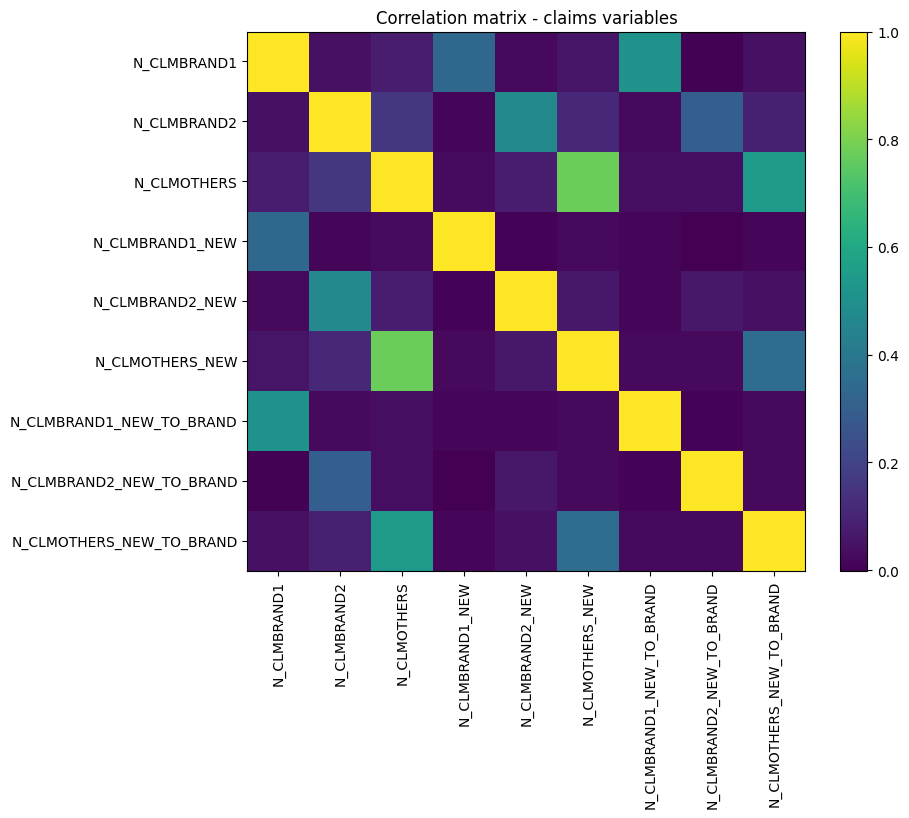

In [108]:
plt.figure(figsize=(9,7))
plt.imshow(corr_claims, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_claims.columns)), corr_claims.columns, rotation=90)
plt.yticks(range(len(corr_claims.index)), corr_claims.index)
plt.title("Correlation matrix - claims variables")
plt.show()

There are not many correlations between the claims variables. 